In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML
display(HTML("<style>.container { width:98% !important; }</style>"))
from pathlib import Path
from collections import Counter
import sys 
sys.path.append('/Users/johnmarshall/Documents/Analysis/JJMezTrackAnalysis')
import gcamp_peak_utils as gp
import imageio.v2 as imageio

In [2]:
salaeCSVfile = '/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/T_maze_data/Raw_salae_miniscope_data/326/raw_326.csv'
salaeData = pd.read_csv(salaeCSVfile)
timestampfile = pd.read_table('/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/T_maze_data/Raw_salae_miniscope_data/326/timeStamps.csv', delimiter=',')


In [3]:
salaeData

,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,Channel 9,Channel 10,Channel 11,Channel 12,Channel 13,Channel 14,Channel 15
0,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,15.041145,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,15.074723,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,15.109140,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,15.141956,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188970,6307.665302,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
188971,6307.699739,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
188972,6307.732507,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
188973,6307.766112,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [4]:
#Match miniscope imaging activity with salae activity

In [5]:
timestampfile


,Frame Number,Time Stamp (ms),Buffer Index
0,0,-98,4
1,1,-64,7
2,2,-32,6
3,3,2,6
4,4,36,5
...,...,...,...
187184,187184,6292549,0
187185,187185,6292583,0
187186,187186,6292615,0
187187,187187,6292649,0


In [6]:
## find rows where channel 12 TTL is alternating 
rows_withMiniscopeTTL = salaeData.loc[
    (salaeData['Channel 12'] != salaeData['Channel 12'].shift(-1)) &
    (salaeData['Channel 12'] == salaeData['Channel 12'].shift(-2))
]
rows_withMiniscopeTTL = rows_withMiniscopeTTL[1:]
rows_withMiniscopeTTL

,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,Channel 9,Channel 10,Channel 11,Channel 12,Channel 13,Channel 14,Channel 15
1,15.041145,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,15.074723,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,15.109140,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,15.141956,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
5,15.175567,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188967,6307.564464,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
188968,6307.599005,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
188969,6307.631866,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
188970,6307.665302,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [7]:
## get delta time in ms between salae samples 
rows_withMiniscopeTTL['Time Delta [ms]'] = abs(rows_withMiniscopeTTL['Time [s]'] - rows_withMiniscopeTTL['Time [s]'].shift(-1))
rows_withMiniscopeTTL['Time Delta [ms]'] = rows_withMiniscopeTTL['Time Delta [ms]']*1000

In [8]:
rows_withMiniscopeTTL

,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,Channel 9,Channel 10,Channel 11,Channel 12,Channel 13,Channel 14,Channel 15,Time Delta [ms]
1,15.041145,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.578
2,15.074723,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,34.417
3,15.109140,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,32.816
4,15.141956,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,33.611
5,15.175567,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34.206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188967,6307.564464,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34.541
188968,6307.599005,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,32.861
188969,6307.631866,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.436
188970,6307.665302,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,34.437


In [9]:
# need these rows where ['Time Delta [s]'] is between 30 to 40 ms this will return periods where the miniscope is actually "recording", 
# i.e. TTLs are recorded at a consistent frequency
MiniscopeRecordingPeriods = rows_withMiniscopeTTL[(rows_withMiniscopeTTL['Time Delta [ms]'] < 40 ) & (rows_withMiniscopeTTL['Time Delta [ms]'] > 30)]
MiniscopeRecordingPeriods['TTL Gap [s]'] = abs(MiniscopeRecordingPeriods['Time [s]'] - MiniscopeRecordingPeriods['Time [s]'].shift(-1))

In [10]:
# Single session – no gap between recording periods to find
MiniscopeRecordingPeriods

,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,Channel 9,Channel 10,Channel 11,Channel 12,Channel 13,Channel 14,Channel 15,Time Delta [ms],TTL Gap [s]
1,15.041145,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.578,0.033578
2,15.074723,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,34.417,0.034417
3,15.109140,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,32.816,0.032816
4,15.141956,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,33.611,0.033611
5,15.175567,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34.206,0.034206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188966,6307.531439,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,33.025,0.033025
188967,6307.564464,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34.541,0.034541
188968,6307.599005,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,32.861,0.032861
188969,6307.631866,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.436,0.033436


In [11]:
# Single session – no split needed

In [12]:
## Single miniscope recording – use all of MiniscopeRecordingPeriods
salaeSamplesMiniscopeRecording = MiniscopeRecordingPeriods.copy()
salaeSamplesMiniscopeRecording

,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,Channel 9,Channel 10,Channel 11,Channel 12,Channel 13,Channel 14,Channel 15,Time Delta [ms],TTL Gap [s]
1,15.041145,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.578,0.033578
2,15.074723,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,34.417,0.034417
3,15.109140,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,32.816,0.032816
4,15.141956,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,33.611,0.033611
5,15.175567,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34.206,0.034206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188966,6307.531439,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,33.025,0.033025
188967,6307.564464,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34.541,0.034541
188968,6307.599005,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,32.861,0.032861
188969,6307.631866,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.436,0.033436


In [13]:
salaeSamplesMiniscopeRecording = MiniscopeRecordingPeriods.copy()

start_time = timestampfile['Time Stamp (ms)'].iloc[0]

salaeSamplesMiniscopeRecording['Salae Miniscope Time (ms)'] = (
    salaeSamplesMiniscopeRecording['Time [s]'] - salaeSamplesMiniscopeRecording['Time [s]'].iloc[0]
) * 1000
salaeSamplesMiniscopeRecording.loc[
    salaeSamplesMiniscopeRecording.index[0], 'Salae Miniscope Time (ms)'
] = start_time
#Adjusts Salae timing to miniscope timing

salaeSamplesMiniscopeRecording = pd.concat([
    salaeSamplesMiniscopeRecording.reset_index(drop=True),
    timestampfile[['Frame Number', 'Time Stamp (ms)']].reset_index(drop=True)
], axis=1)

# after the pd.concat:
salaeSamplesMiniscopeRecording = salaeSamplesMiniscopeRecording.dropna(subset=['Time [s]'])

In [14]:
#alternative approach, find the miniscope frame where the 'Time Stamp (ms)' was closest in absolute value to the
#'Salae Miniscope Time (ms)' value , needs to have the "np.nan if pd.isna(x)" for the rows where 'Salae Miniscope Time (ms)' is NaN
salaeSamplesMiniscopeRecording['Corresponding Miniscope Frame'] = (
    salaeSamplesMiniscopeRecording['Salae Miniscope Time (ms)'].apply(
        lambda x: np.nan if pd.isna(x) else salaeSamplesMiniscopeRecording.loc[
            (salaeSamplesMiniscopeRecording['Time Stamp (ms)'] - x).abs().idxmin(),
            'Frame Number'
        ]
    )
)

In [15]:
salaeSamplesMiniscopeRecordingTruncated = salaeSamplesMiniscopeRecording[salaeSamplesMiniscopeRecording['Corresponding Miniscope Frame'].notna()] 
salaeSamplesMiniscopeRecordingTruncated


,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,...,Channel 12,Channel 13,Channel 14,Channel 15,Time Delta [ms],TTL Gap [s],Salae Miniscope Time (ms),Frame Number,Time Stamp (ms),Corresponding Miniscope Frame
0,15.041145,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,33.578,0.033578,-98.000,0,-98,0
1,15.074723,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,34.417,0.034417,33.578,1,-64,4
2,15.109140,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,32.816,0.032816,67.995,2,-32,5
3,15.141956,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,33.611,0.033611,100.811,3,2,6
4,15.175567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,34.206,0.034206,134.422,4,36,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182351,6307.531439,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,33.025,0.033025,6292490.294,182351,6129822,182355
182352,6307.564464,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,34.541,0.034541,6292523.319,182352,6129855,182355
182353,6307.599005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,32.861,0.032861,6292557.860,182353,6129889,182355
182354,6307.631866,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,33.436,0.033436,6292590.721,182354,6129923,182355


In [16]:
salaeSamplesMiniscopeRecording
salaeSamplesMiniscopeRecording.to_csv('/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/T_maze_data/Raw_salae_miniscope_data/326/salaeSamplesMiniscopeRecording.csv')


In [17]:
# --- Load aligned salae ---

salae = pd.read_csv('/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/T_maze_data/Raw_salae_miniscope_data/326/salaeSamplesMiniscopeRecording.csv')

# --- Find Ch11 rising edges ---

ch11_rises = salae[
    (salae["Channel 11"] == 1) & (salae["Channel 11"].shift(1) == 0)
]["Time [s]"].values

# --- Find Ch6 falling edges (delay start) ---

ch6_falling = salae[
    (salae["Channel 6"] == 0) & (salae["Channel 6"].shift(1) == 1)
]["Time [s]"].values

# --- Find last Ch3 or Ch4 rising edge before each Ch6 falling edge (which arm was forced) ---

ch3_rising = salae[
    (salae["Channel 3"] == 1) & (salae["Channel 3"].shift(1) == 0)
][["Time [s]"]].copy()
ch3_rising["forced_side"] = "left"

ch4_rising = salae[
    (salae["Channel 4"] == 1) & (salae["Channel 4"].shift(1) == 0)
][["Time [s]"]].copy()
ch4_rising["forced_side"] = "right"

ch34_rising = pd.concat([ch3_rising, ch4_rising]).sort_values("Time [s]")

# --- For each Ch11 rising edge, find the preceding Ch6 falling edge ---
# and classify as a real delay period (5s or 30s only)

delay_trials = []
trial_number = 0

for t11 in ch11_rises:
    # find last Ch6 falling edge before this Ch11
    preceding_ch6 = ch6_falling[ch6_falling < t11]
    if len(preceding_ch6) == 0:
        continue

    delay_start_time = preceding_ch6[-1]
    gap = t11 - delay_start_time

    # only keep real delay periods
    if 4 < gap < 8:
        delay_type = 5
    elif 25 < gap < 35:
        delay_type = 30
    else:
        continue  # skip 0s trials

    # find last Ch3/Ch4 rising edge before the Ch6 falling edge
    preceding_ch34 = ch34_rising[ch34_rising["Time [s]"] < delay_start_time]
    if len(preceding_ch34) == 0:
        forced_side = "unknown"
    else:
        forced_side = preceding_ch34.iloc[-1]["forced_side"]

    # find closest miniscope frames
    start_idx = (salae["Time [s]"] - delay_start_time).abs().idxmin()
    end_idx = (salae["Time [s]"] - t11).abs().idxmin()

    trial_number += 1

    delay_trials.append({
        "trial_number": trial_number,
        "forced_side": forced_side,
        "delay_duration_s": round(gap, 3),
        "delay_start_time": delay_start_time,
        "delay_end_time": t11,
        "delay_start_frame": salae.loc[start_idx, "Corresponding Miniscope Frame"],
        "delay_end_frame": salae.loc[end_idx, "Corresponding Miniscope Frame"]
    })

delay_df = pd.DataFrame(delay_trials)

delay_df.to_csv('/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/T_maze_data/Raw_salae_miniscope_data/388/delay_periods.csv', index=False)

print(f"Total delay trials: {len(delay_df)}")
print(f"  5s delays:  {len(delay_df[delay_df.delay_duration_s < 10])}")
print(f"  30s delays: {len(delay_df[delay_df.delay_duration_s > 10])}")
print(f"  Left forced:  {len(delay_df[delay_df.forced_side == 'left'])}")
print(f"  Right forced: {len(delay_df[delay_df.forced_side == 'right'])}")

display(delay_df)


Total delay trials: 24
  5s delays:  12
  30s delays: 12
  Left forced:  12
  Right forced: 12


,trial_number,forced_side,delay_duration_s,delay_start_time,delay_end_time,delay_start_frame,delay_end_frame
0,1,right,5.411,69.821009,75.231614,1633,1794
1,2,left,29.977,232.581220,262.558620,6476,7368
2,3,left,5.210,501.134641,506.344354,14467,14622
3,4,right,30.380,806.657670,837.037714,23549,24453
4,5,right,30.616,952.378106,982.994299,27883,28794
5,6,left,5.345,1173.915284,1179.259847,34475,34634
6,7,right,5.007,1287.507590,1292.514846,37854,38002
7,8,left,31.019,1459.071581,1490.090918,42957,43881
8,9,left,5.478,1836.748279,1842.226587,54195,54358
9,10,left,29.876,1951.651294,1981.527354,57614,58496


In [ ]:
## align calcium traces 

In [70]:
## for creating validation videos 

#cell video activity during delay period 

pathToEXTRACT = "/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/T_maze_data/ExtractOutput_052026/m326/20260603_224001_271/_denoised_converted_concat_ds_mc_det_20260603_224001_271.mat"

delay_row = 10
cell_name = "cell_242"

row = delay_df.iloc[delay_row]
start_frame = int(row["delay_start_frame"])
end_frame = int(row["delay_end_frame"])

center_idx = (start_frame + end_frame) // 2
before = center_idx - start_frame
after = end_frame - center_idx + 1

save_dir = Path("/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/T_maze_data/T_mazeImagingAnalysis/m326/")
save_path = save_dir / f"{cell_name}_delay_trial_{int(row['trial_number']):02d}.mp4"

print(Path(pathToEXTRACT).exists(), save_dir.exists())


movie_uint8, meta = gp.build_single_cell_peak_movie(
    pathToEXTRACT,
    cell_name,
    center_idx,
    window=(before, after),
    stats_df=None,
    include_all_cells=True,
    highlight_cell=True,
    highlight_strength=1.0,
)

if movie_uint8.shape[2] % 2 != 0:  # width is odd
    if movie_uint8.ndim == 4:
        pad = np.zeros((movie_uint8.shape[0], movie_uint8.shape[1], 1, movie_uint8.shape[3]), dtype=movie_uint8.dtype)
    else:
        pad = np.zeros((movie_uint8.shape[0], movie_uint8.shape[1], 1), dtype=movie_uint8.dtype)
    movie_uint8 = np.concatenate([movie_uint8, pad], axis=2)

if movie_uint8.shape[1] % 2 != 0:  # height is odd
    if movie_uint8.ndim == 4:
        pad = np.zeros((movie_uint8.shape[0], 1, movie_uint8.shape[2], movie_uint8.shape[3]), dtype=movie_uint8.dtype)
    else:
        pad = np.zeros((movie_uint8.shape[0], 1, movie_uint8.shape[2]), dtype=movie_uint8.dtype)
    movie_uint8 = np.concatenate([movie_uint8, pad], axis=1)


imageio.mimsave(
    save_path,
    movie_uint8,
    fps=20,
    macro_block_size=1,
)

print(save_path)

True True
/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/T_maze_data/T_mazeImagingAnalysis/m326/cell_242_delay_trial_11.mp4


In [ ]:
# Removed – single session, no session 2


In [34]:
## load calcium traces 
calciumData = pd.read_table('/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/T_maze_data/ExtractOutput_052026/m326/20260603_224001_271/_C_traces_filtered_origHz.csv', delimiter=',')


In [35]:
calciumData

,Unnamed: 0,cell_0,cell_1,cell_8,cell_9,cell_16,cell_20,cell_21,cell_22,cell_23,...,cell_207,cell_209,cell_217,cell_223,cell_225,cell_226,cell_235,cell_236,cell_237,cell_242
0,0 days 00:00:00,-0.248825,1.502958,-0.588964,0.464800,-0.573028,-0.614331,-0.193407,-0.414529,1.971959,...,-0.427876,0.278360,-0.689758,-0.601340,-0.658929,-0.396751,-0.552790,0.024222,-0.455220,0.424611
1,0 days 00:00:00.050000,-0.524949,1.678598,0.059196,0.416933,-0.573028,-0.614331,-0.499145,-0.139476,0.805758,...,-0.099547,0.351446,0.759733,-0.601340,-0.683473,0.388142,-0.499814,1.155138,-0.642758,-0.625483
2,0 days 00:00:00.100000,-0.524949,1.042079,-0.208998,0.111308,-0.315899,0.451482,-0.499145,-0.192734,1.175370,...,0.614135,-0.284902,0.210099,2.280584,-0.683473,-0.370805,0.070897,-0.087785,-0.642758,2.101267
3,0 days 00:00:00.150000,1.028117,-0.641561,-0.588964,-0.661641,-0.036285,-0.614331,-0.499145,-0.414529,0.080108,...,-0.395263,-0.060911,-0.409594,-0.543737,-0.683473,-0.396751,0.099108,-0.222256,-0.256909,-0.625483
4,0 days 00:00:00.200000,0.259598,0.109391,0.178426,0.415521,-0.573028,1.383339,-0.499145,-0.414529,-0.269765,...,-0.427876,-0.284902,0.986367,-0.601340,0.370688,-0.396751,-0.552790,0.111037,-0.642758,-0.244076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187184,0 days 02:35:59.200000,-0.274420,-0.107252,-0.588964,1.535896,0.618814,-0.084018,-0.499145,-0.414529,0.635754,...,-0.427876,-0.284902,-0.689758,0.367048,-0.683473,1.177151,-0.552790,0.093251,0.038808,0.556507
187185,0 days 02:35:59.250000,0.530036,-0.633779,-0.576832,-0.204388,-0.573028,-0.614331,1.026325,-0.414529,-0.546446,...,-0.323689,-0.284902,-0.689758,-0.601340,-0.683473,-0.037906,-0.339685,1.475697,2.845216,1.025488
187186,0 days 02:35:59.300000,1.041190,-0.641561,-0.588964,0.931359,-0.238236,-0.155871,0.512099,-0.414529,-0.459415,...,-0.427876,-0.284902,-0.262097,-0.518009,-0.683473,-0.396751,-0.107580,0.135285,1.653828,1.088589
187187,0 days 02:35:59.350000,-0.207050,-0.161594,-0.588964,-0.177587,0.627909,0.907186,-0.499145,-0.414529,-0.546446,...,-0.427876,-0.284902,0.753368,-0.601340,-0.683473,0.249991,-0.552790,-0.313061,0.401738,0.742309


In [37]:
calciumData['cell_0'][1633:1794]

1633    2.830318
1634    0.180507
1635    0.226672
1636   -0.524949
1637   -0.318704
          ...   
1789   -0.524949
1790   -0.524949
1791   -0.524949
1792   -0.044119
1793   -0.524949
Name: cell_0, Length: 161, dtype: float64

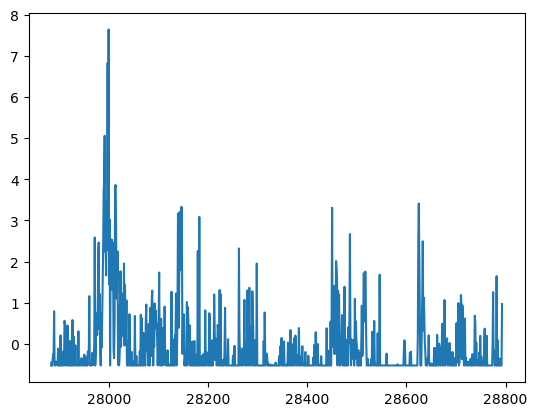

In [50]:
delayTrial=4
plt.plot(calciumData['cell_0'][delay_df.loc[delayTrial]['delay_start_frame']:delay_df.loc[delayTrial]['delay_end_frame']])

In [79]:
## functions for visualization
def load_calcium_traces(csv_path):
    csv_path = Path(csv_path)
    traces_df = pd.read_csv(csv_path)

    # The first column in your file is time-like; keep it if present.
    first_col = traces_df.columns[0]
    if str(first_col).startswith("Unnamed:"):
        traces_df = traces_df.rename(columns={first_col: "time"})
        try:
            traces_df["time"] = pd.to_timedelta(traces_df["time"])
        except Exception:
            pass

    return traces_df


def extract_delay_trace(traces_df, delay_periods_df, cell, trial_number=None, delay_row=None):
    """
    Extract one cell's calcium trace during one delay period.

    Parameters
    ----------
    traces_df : pd.DataFrame
        Calcium dataframe loaded from 328_C_traces_filtered_origHz.csv
    delay_periods_df : pd.DataFrame
        Dataframe with delay_start_frame / delay_end_frame
    cell : str or int
        Example: 'cell_28' or 28
    trial_number : int, optional
        Trial number from the delay dataframe
    delay_row : int, optional
        Row index in delay_periods_df (use this if not selecting by trial_number)

    Returns
    -------
    pd.DataFrame
        Slice with frame index, optional time, and the selected cell trace
    """
    if isinstance(cell, int):
        cell = f"cell_{cell}"

    if trial_number is not None:
        row = delay_periods_df.loc[delay_periods_df["trial_number"] == trial_number]
        if row.empty:
            raise ValueError(f"No row found for trial_number={trial_number}")
        if len(row) > 1:
            raise ValueError(f"Multiple rows found for trial_number={trial_number}")
        row = row.iloc[0]
    elif delay_row is not None:
        row = delay_periods_df.iloc[delay_row]
    else:
        raise ValueError("Provide either trial_number or delay_row")

    if cell not in traces_df.columns:
        raise ValueError(f"{cell} not found in traces_df")

    start_frame = int(row["delay_start_frame"])
    end_frame = int(row["delay_end_frame"])

    # end_frame is treated as inclusive
    out = traces_df.iloc[start_frame:end_frame + 1].copy()
    out["frame"] = range(start_frame, end_frame + 1)

    keep_cols = ["frame", cell]
    if "time" in out.columns:
        keep_cols.insert(1, "time")

    return out[keep_cols]


def plot_cell_during_delay(traces_df, delay_periods_df, cell, trial_number=None, delay_row=None):
    delay_trace_df = extract_delay_trace(
        traces_df=traces_df,
        delay_periods_df=delay_periods_df,
        cell=cell,
        trial_number=trial_number,
        delay_row=delay_row,
    )

    cell_name = f"cell_{cell}" if isinstance(cell, int) else cell

    fig, ax = plt.subplots(figsize=(8, 3.5))

    ax.plot(delay_trace_df["frame"], delay_trace_df[cell_name], linewidth=1.5)
    ax.set_xlabel("Miniscope frame")
    ax.set_ylabel("Calcium signal")
    ax.set_title(
        f"{cell_name} during delay "
        f"(trial {trial_number if trial_number is not None else delay_periods_df.iloc[delay_row]['trial_number']})"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

    return delay_trace_df

def cells_active_in_delay(
    calciumData,
    delay_periods_df,
    delay_row,
    threshold=2.5,
    min_consecutive_frames=1,
    cell_prefix="cell_",
):
    start_frame = int(delay_periods_df.iloc[delay_row]["delay_start_frame"])
    end_frame = int(delay_periods_df.iloc[delay_row]["delay_end_frame"])

    delay_slice = calciumData.iloc[start_frame:end_frame + 1]
    cell_cols = [c for c in delay_slice.columns if str(c).startswith(cell_prefix)]

    active_cells = []
    for cell in cell_cols:
        vals = pd.to_numeric(delay_slice[cell], errors="coerce").to_numpy()
        above = vals > threshold

        if min_consecutive_frames <= 1:
            is_active = np.any(above)
        else:
            is_active = np.any(
                np.convolve(above.astype(int), np.ones(min_consecutive_frames, dtype=int), mode="valid")
                >= min_consecutive_frames
            )

        if is_active:
            active_cells.append(cell)

    return active_cells

def plot_input_cell_active_delays_stacked(
    cell,
    calciumData,
    delay_periods_df,
    active_cells_summary_df,
    figsize_per_row=1.8,
    color="black",
    sharex=False,
):
    if isinstance(cell, int):
        cell = f"cell_{cell}"

    active_trials = active_cells_summary_df.loc[
        active_cells_summary_df["active_cells"].apply(lambda cells: cell in cells),
        "trial_number"
    ].tolist()

    plot_df = delay_periods_df.loc[
        delay_periods_df["trial_number"].isin(active_trials)
    ].copy()

    if plot_df.empty:
        print(f"{cell} is not active in any of the selected delay periods.")
        return

    n = len(plot_df)
    fig, axes = plt.subplots(
        n, 1,
        figsize=(10, figsize_per_row * n),
        sharex=sharex
    )

    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, plot_df.iterrows()):
        start_frame = int(row["delay_start_frame"])
        end_frame = int(row["delay_end_frame"])

        y = pd.to_numeric(
            calciumData[cell].iloc[start_frame:end_frame + 1],
            errors="coerce"
        ).to_numpy()

        x = np.arange(start_frame, end_frame + 1)

        ax.plot(x, y, color=color, linewidth=1.4)
        ax.set_ylabel(cell)
        ax.set_title(
            f"Trial {int(row['trial_number'])} | "
            f"{row['forced_side']} | "
            f"{row['delay_duration_s']:.2f} s"
        )
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[-1].set_xlabel("Miniscope frame")
    fig.suptitle(f"{cell}: activity during selected delay periods with events", y=1.02)

    plt.tight_layout()
    plt.show()

def correlate_input_cell_across_delays(
    cell,
    calciumData,
    delay_periods_df,
    threshold=2.5,
    bin_width_frames=5,
    active_cells_summary_df=None,
    only_active_delays=True,
    binarize_mode="any",   # "any" or "mean"
):
    if isinstance(cell, int):
        cell = f"cell_{cell}"

    work_df = delay_periods_df.copy()

    if active_cells_summary_df is not None and only_active_delays:
        active_trials = active_cells_summary_df.loc[
            active_cells_summary_df["active_cells"].apply(lambda cells: cell in cells),
            "trial_number"
        ].tolist()
        work_df = work_df.loc[work_df["trial_number"].isin(active_trials)].copy()

    if work_df.empty:
        print(f"No matching delay periods found for {cell}.")
        return None, None, None

    binarized_traces = []
    labels = []
    meta_rows = []

    for _, row in work_df.iterrows():
        start_frame = int(row["delay_start_frame"])
        end_frame = int(row["delay_end_frame"])

        y = pd.to_numeric(
            calciumData[cell].iloc[start_frame:end_frame + 1],
            errors="coerce"
        ).to_numpy()

        n_full_bins = len(y) // bin_width_frames
        if n_full_bins < 1:
            continue

        y = y[:n_full_bins * bin_width_frames].reshape(n_full_bins, bin_width_frames)

        if binarize_mode == "any":
            b = (np.nanmax(y, axis=1) > threshold).astype(int)
        elif binarize_mode == "mean":
            b = (np.nanmean(y, axis=1) > threshold).astype(int)
        else:
            raise ValueError("binarize_mode must be 'any' or 'mean'")

        binarized_traces.append(b)
        labels.append(f"T{int(row['trial_number'])}")
        meta_rows.append({
            "trial_number": int(row["trial_number"]),
            "forced_side": row["forced_side"],
            "delay_duration_s": row["delay_duration_s"],
            "n_bins": len(b),
        })

    if len(binarized_traces) < 2:
        print(f"Need at least 2 delay periods to compute correlations for {cell}.")
        return None, None, pd.DataFrame(meta_rows)

    min_len = min(len(x) for x in binarized_traces)
    X = np.vstack([x[:min_len] for x in binarized_traces])

    corr = np.full((X.shape[0], X.shape[0]), np.nan, dtype=float)
    for i in range(X.shape[0]):
        for j in range(X.shape[0]):
            xi = X[i]
            xj = X[j]
            if np.std(xi) == 0 or np.std(xj) == 0:
                corr[i, j] = 1.0 if i == j else np.nan
            else:
                corr[i, j] = np.corrcoef(xi, xj)[0, 1]

    corr_df = pd.DataFrame(corr, index=labels, columns=labels)
    binned_df = pd.DataFrame(X, index=labels, columns=[f"bin_{i}" for i in range(min_len)])
    meta_df = pd.DataFrame(meta_rows, index=labels)

    return corr_df, binned_df, meta_df



In [80]:
# list cells active during defined delay periods
active_cells_summary = []
for delay_row in range(len(delay_df)):
    active_cells = cells_active_in_delay(
        calciumData=calciumData,
        delay_periods_df=delay_df,
        delay_row=delay_row,
        threshold=2.5,
        min_consecutive_frames=2,
    )
    active_cells_summary.append({
        "delay_row": delay_row,
        "trial_number": delay_df.iloc[delay_row]["trial_number"],
        "forced_side": delay_df.iloc[delay_row]["forced_side"],
        "delay_duration_s": delay_df.iloc[delay_row]["delay_duration_s"],
        "n_active_cells": len(active_cells),
        "active_cells": active_cells,
    })
active_cells_summary_df = pd.DataFrame(active_cells_summary)
active_cells_summary_df

,delay_row,trial_number,forced_side,delay_duration_s,n_active_cells,active_cells
0,0,1,right,5.411,25,"[cell_8, cell_23, cell_39, cell_43, cell_53, c..."
1,1,2,left,29.977,56,"[cell_1, cell_8, cell_9, cell_16, cell_21, cel..."
2,2,3,left,5.210,27,"[cell_8, cell_20, cell_21, cell_23, cell_89, c..."
3,3,4,right,30.380,60,"[cell_0, cell_1, cell_8, cell_9, cell_16, cell..."
4,4,5,right,30.616,58,"[cell_0, cell_1, cell_8, cell_9, cell_16, cell..."
5,5,6,left,5.345,17,"[cell_27, cell_74, cell_95, cell_102, cell_104..."
6,6,7,right,5.007,23,"[cell_0, cell_8, cell_16, cell_23, cell_37, ce..."
7,7,8,left,31.019,71,"[cell_0, cell_1, cell_8, cell_9, cell_16, cell..."
8,8,9,left,5.478,19,"[cell_8, cell_16, cell_23, cell_37, cell_43, c..."
9,9,10,left,29.876,68,"[cell_8, cell_9, cell_16, cell_20, cell_21, ce..."


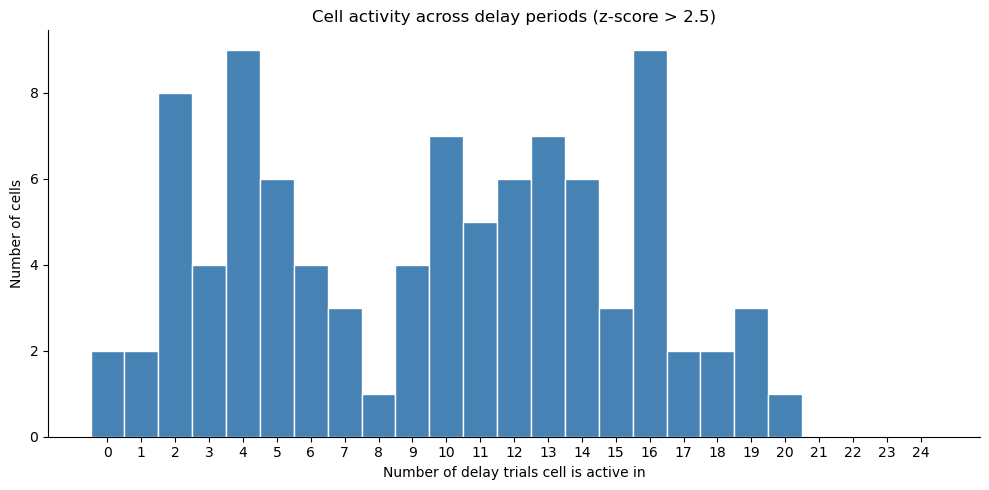

In [81]:
# Histogram: number of cells active in N delay trials
cell_cols = [c for c in calciumData.columns if str(c).startswith('cell_')]
total_trials = len(delay_df)

trial_counts = []
for cell in cell_cols:
    count = sum(cell in row for row in active_cells_summary_df['active_cells'])
    trial_counts.append(count)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(trial_counts, bins=range(0, total_trials + 2), align='left', color='steelblue', edgecolor='white')
ax.set_xlabel('Number of delay trials cell is active in')
ax.set_ylabel('Number of cells')
ax.set_title('Cell activity across delay periods (z-score > 2.5)')
ax.set_xticks(range(0, total_trials + 1))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

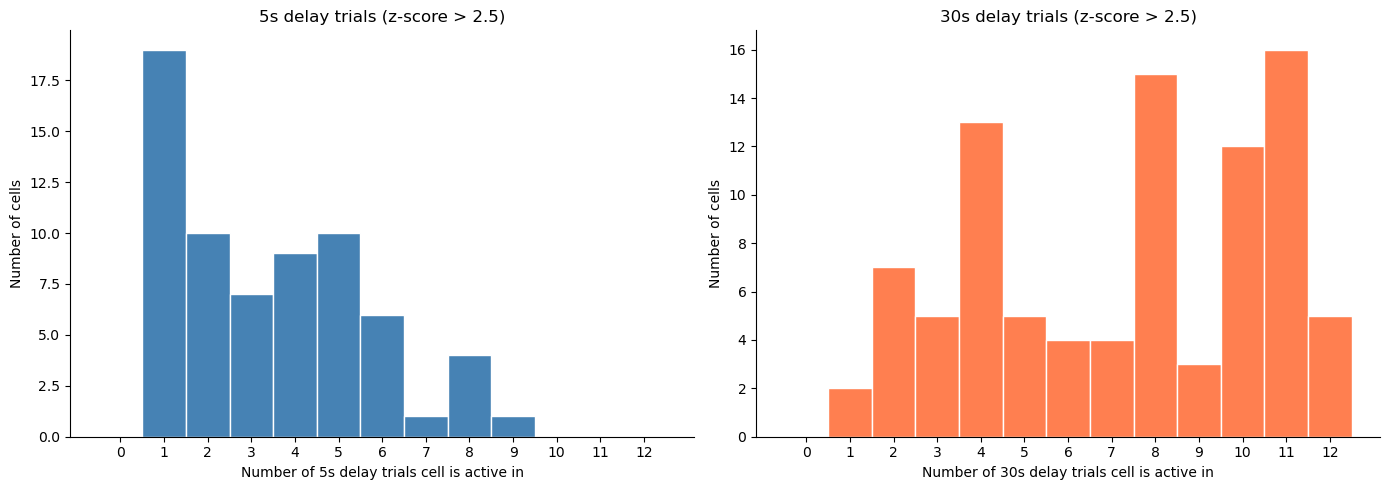

In [82]:
trial_counts_5s = []
trial_counts_30s = []

trials_5s = delay_df[delay_df['delay_duration_s'] < 10]['trial_number'].tolist()
trials_30s = delay_df[delay_df['delay_duration_s'] > 10]['trial_number'].tolist()

for cell in cell_cols:
    count_5s = sum(cell in row for row in active_cells_summary_df[active_cells_summary_df['trial_number'].isin(trials_5s)]['active_cells'])
    count_30s = sum(cell in row for row in active_cells_summary_df[active_cells_summary_df['trial_number'].isin(trials_30s)]['active_cells'])
    trial_counts_5s.append(count_5s)
    trial_counts_30s.append(count_30s)
    
trial_counts_5s_active = [x for x in trial_counts_5s if x > 0]
trial_counts_30s_active = [x for x in trial_counts_30s if x > 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(trial_counts_5s_active, bins=range(0, len(trials_5s) + 2), align='left', color='steelblue', edgecolor='white')
ax1.set_xlabel('Number of 5s delay trials cell is active in')
ax1.set_ylabel('Number of cells')
ax1.set_title('5s delay trials (z-score > 2.5)')
ax1.set_xticks(range(0, len(trials_5s) + 1))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2.hist(trial_counts_30s_active, bins=range(0, len(trials_30s) + 2), align='left', color='coral', edgecolor='white')
ax2.set_xlabel('Number of 30s delay trials cell is active in')
ax2.set_ylabel('Number of cells')
ax2.set_title('30s delay trials (z-score > 2.5)')
ax2.set_xticks(range(0, len(trials_30s) + 1))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig('/Users/louisflagel/Downloads/Contractor Data Analysis/MiniscopeRecordingAlignment/388/histogram_by_delay.png', dpi=300, bbox_inches='tight')
plt.show()

In [58]:
# cells active in all delay periods 
cellsActiveInAllDataFrames=sorted(set.intersection(*map(set, active_cells_summary_df["active_cells"])))
print(cellsActiveInAllDataFrames) 
# cells most active across delay periods
cell_counts = Counter(cell for cells in active_cells_summary_df["active_cells"] for cell in cells)
sorted_cells = cell_counts.most_common()
print(sorted_cells)

[]
[('cell_242', 20), ('cell_95', 19), ('cell_104', 19), ('cell_154', 19), ('cell_157', 18), ('cell_194', 18), ('cell_172', 17), ('cell_180', 17), ('cell_8', 16), ('cell_23', 16), ('cell_147', 16), ('cell_150', 16), ('cell_190', 16), ('cell_207', 16), ('cell_98', 16), ('cell_111', 16), ('cell_225', 16), ('cell_53', 15), ('cell_73', 15), ('cell_97', 15), ('cell_89', 14), ('cell_223', 14), ('cell_16', 14), ('cell_133', 14), ('cell_144', 14), ('cell_237', 14), ('cell_92', 13), ('cell_105', 13), ('cell_119', 13), ('cell_123', 13), ('cell_138', 13), ('cell_37', 13), ('cell_205', 13), ('cell_43', 12), ('cell_9', 12), ('cell_51', 12), ('cell_65', 12), ('cell_106', 12), ('cell_107', 12), ('cell_39', 11), ('cell_1', 11), ('cell_74', 11), ('cell_146', 11), ('cell_151', 11), ('cell_48', 10), ('cell_94', 10), ('cell_130', 10), ('cell_131', 10), ('cell_135', 10), ('cell_217', 10), ('cell_126', 10), ('cell_27', 9), ('cell_236', 9), ('cell_20', 9), ('cell_38', 9), ('cell_103', 8), ('cell_102', 7), ('

In [60]:
cell = "cell_242"
active_cells_summary_df.loc[
    active_cells_summary_df["active_cells"].map(lambda x: cell in x),
    ["delay_row", "trial_number", "forced_side", "delay_duration_s"]
]


,delay_row,trial_number,forced_side,delay_duration_s
0,0,1,right,5.411
1,1,2,left,29.977
2,2,3,left,5.210
3,3,4,right,30.380
4,4,5,right,30.616
5,5,6,left,5.345
6,6,7,right,5.007
7,7,8,left,31.019
8,8,9,left,5.478
9,9,10,left,29.876


In [ ]:
delay_df[delay_df['delay_duration_s']>6]

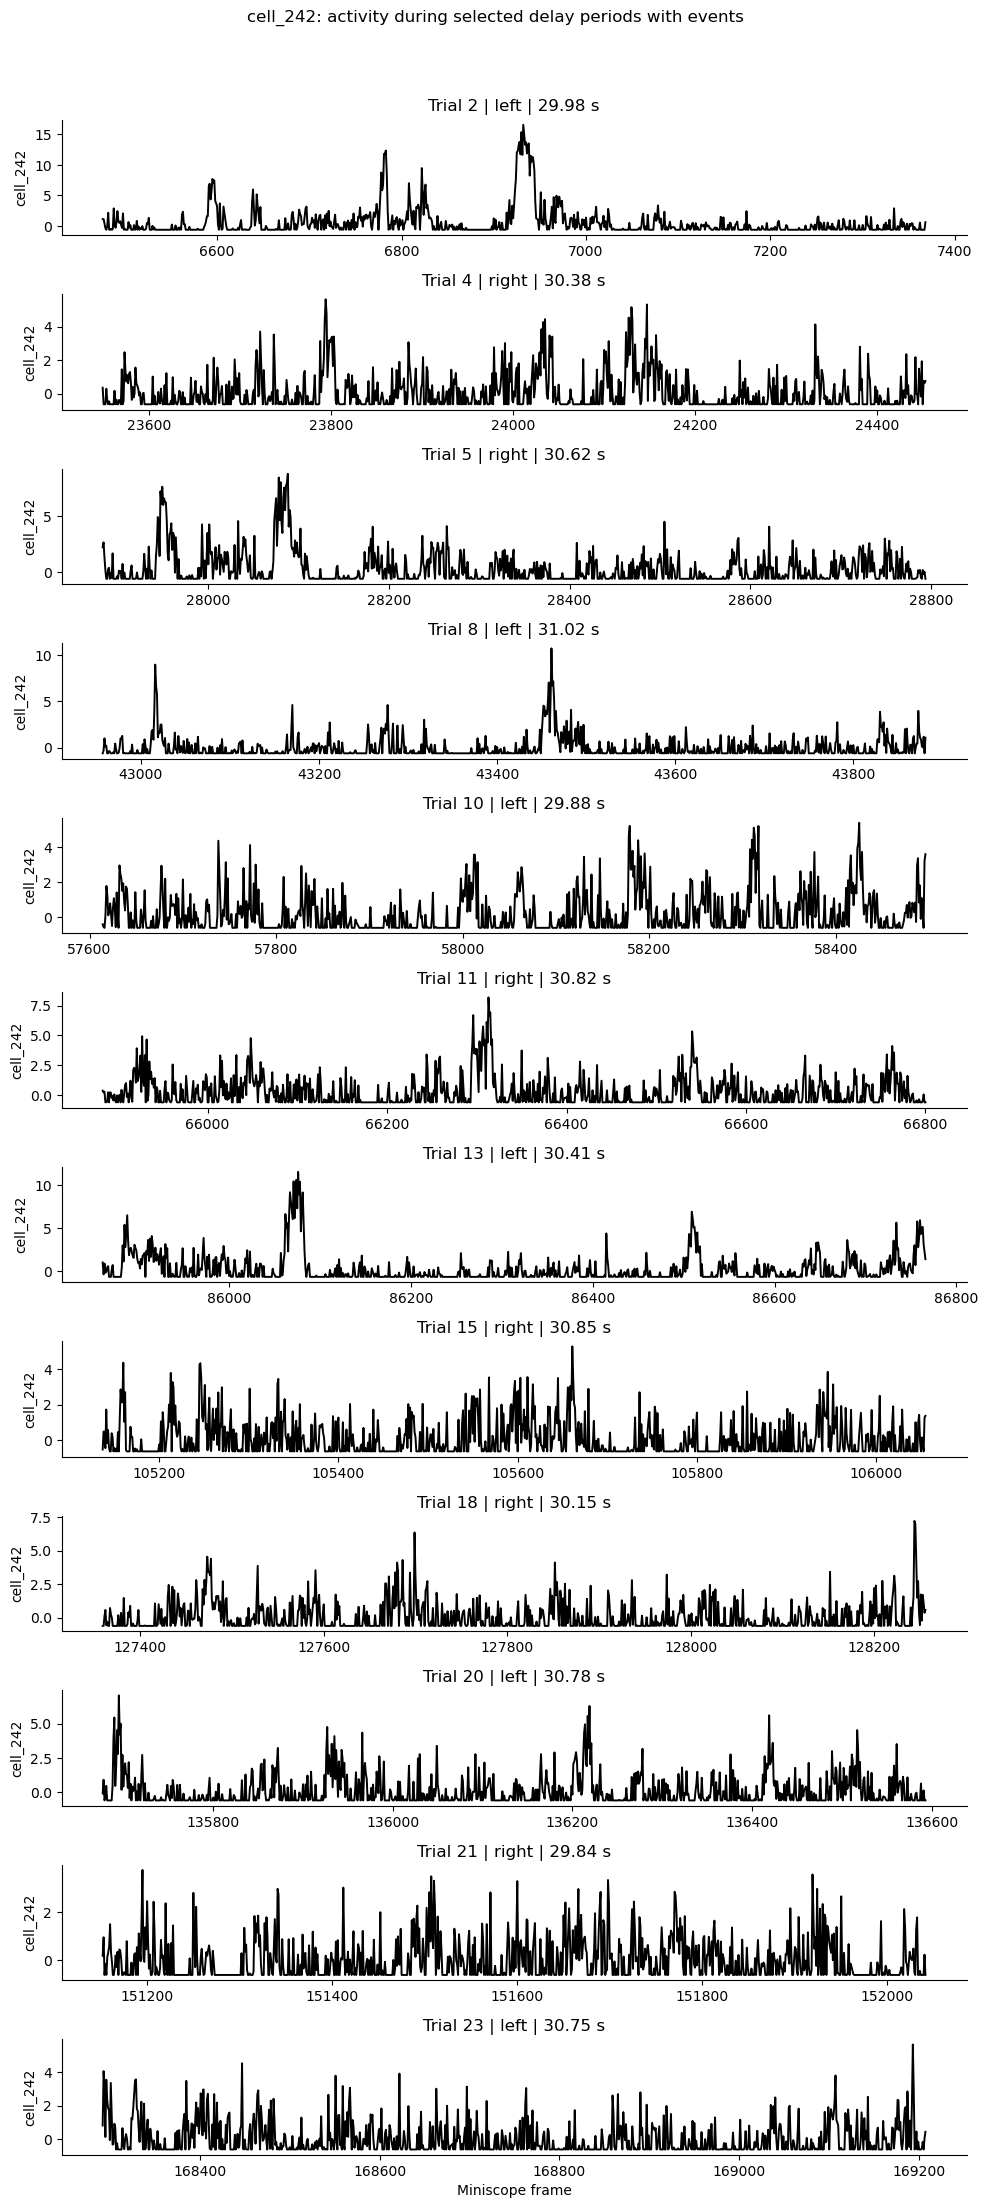

In [71]:
plot_input_cell_active_delays_stacked(
    cell="cell_242",
    calciumData=calciumData,
    delay_periods_df=delay_df[delay_df['delay_duration_s']>6],
    active_cells_summary_df=active_cells_summary_df,
)


In [77]:
corr_df_5_sec, binned_df_5_sec, meta_df_5_sec = correlate_input_cell_across_delays(
    cell="cell_242",
    calciumData=calciumData,
    delay_periods_df=delay_df[delay_df["delay_duration_s"] < 6],
    active_cells_summary_df=active_cells_summary_df,
    threshold=2.5,
    bin_width_frames=30,
    binarize_mode="any",
)

corr_df_5_sec

,T1,T3,T6,T7,T9,T16,T17,T22
T1,1.00000,-0.577350,NaN,-0.577350,1.00000,0.577350,-0.577350,-0.577350
T3,-0.57735,1.000000,NaN,0.333333,-0.57735,-0.333333,-0.333333,1.000000
T6,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
T7,-0.57735,0.333333,NaN,1.000000,-0.57735,-1.000000,0.333333,0.333333
T9,1.00000,-0.577350,NaN,-0.577350,1.00000,0.577350,-0.577350,-0.577350
T16,0.57735,-0.333333,NaN,-1.000000,0.57735,1.000000,-0.333333,-0.333333
T17,-0.57735,-0.333333,NaN,0.333333,-0.57735,-0.333333,1.000000,-0.333333
T22,-0.57735,1.000000,NaN,0.333333,-0.57735,-0.333333,-0.333333,1.000000


In [78]:
avg_corr_5_sec = corr_df_5_sec.where(np.triu(np.ones(corr_df_5_sec.shape, dtype=bool), k=1)).stack().mean()
avg_corr_5_sec

np.float64(-0.14908420389544863)

In [ ]:
plot_input_cell_active_delays_stacked(
    cell="cell_95",
    calciumData=calciumData,
    delay_periods_df=delay_df[delay_df['delay_duration_s']>6],
    active_cells_summary_df=active_cells_summary_df,
)

In [ ]:
corr_df_30_sec, binned_df_30_sec, meta_df_30_sec = correlate_input_cell_across_delays(
    cell="cell_95",
    calciumData=calciumData,
    delay_periods_df=delay_df[delay_df["delay_duration_s"] > 6],
    active_cells_summary_df=active_cells_summary_df,
    threshold=2.5,
    bin_width_frames=20,
    binarize_mode="any",
)

corr_df_30_sec